In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [20]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [21]:
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

In [22]:
BATCH_SIZE = 64

In [23]:
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

In [24]:
activation_fn = nn.Sigmoid()

In [25]:
class FashionNet(nn.Module):
    def __init__(self, activation_fn):
        super(FashionNet, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),               # It turns [64, 1, 28, 28] into [64, 784]
            nn.Linear(784, 512),
            activation_fn,
            nn.Linear(512, 256),
            activation_fn,
            nn.Linear(256, 128),
            activation_fn,
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)

In [26]:
def train_model(name, activation_fn, epochs=5):
    print(f"\nTraining Model with {name}...")

In [27]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cpu


In [28]:
model = FashionNet(activation_fn).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
history = []


In [29]:
epochs = 10

In [30]:
for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            # 1. Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # 2. Backward pass
            optimizer.zero_grad()
            loss.backward()
            
            # 3. Optimization step
            optimizer.step()
            
            running_loss += loss.item()
            
        avg_loss = running_loss / len(train_loader)
        history.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

Epoch 1/10 - Loss: 0.6998
Epoch 2/10 - Loss: 0.4078
Epoch 3/10 - Loss: 0.3595
Epoch 4/10 - Loss: 0.3248
Epoch 5/10 - Loss: 0.3058
Epoch 6/10 - Loss: 0.2871
Epoch 7/10 - Loss: 0.2712
Epoch 8/10 - Loss: 0.2597
Epoch 9/10 - Loss: 0.2466
Epoch 10/10 - Loss: 0.2356


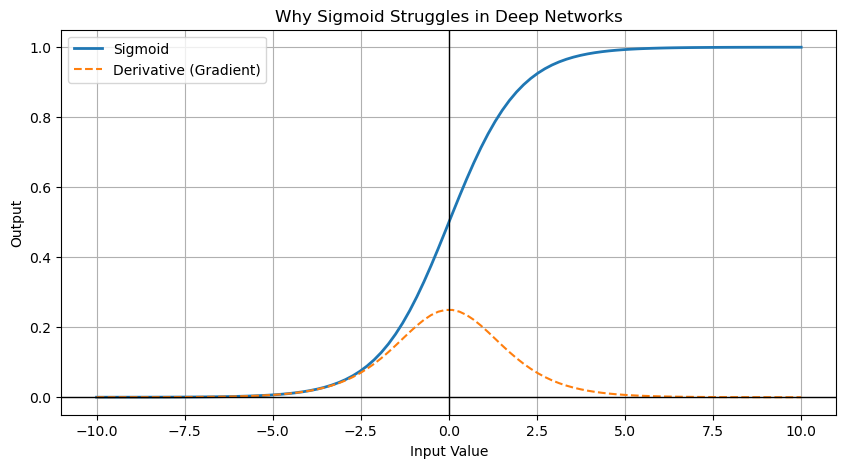

In [40]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

x = np.linspace(-10, 10, 100)

plt.figure(figsize=(10, 5))
plt.plot(x, sigmoid(x), label='Sigmoid', linewidth=2)
plt.plot(x, sigmoid_derivative(x), label='Derivative (Gradient)', linestyle='--')
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("Why Sigmoid Struggles in Deep Networks")
plt.xlabel("Input Value")
plt.ylabel("Output")
plt.legend()
plt.grid(True)
plt.show()

The Vanishing Signal: Because the derivative of Sigmoid is so small (max 0.25), by the time the gradient reaches Layer 1 from Layer 5, it has been multiplied by 0.25. This means the weights in the deeper layers barely change from their random starting values.

In [41]:
model.eval()

correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print(f'Test Accuracy: {accuracy:.2f}%')

Test Accuracy: 88.35%


In [53]:
activation_fn_relu = nn.ReLU()

In [54]:
class FashionNetReLU(nn.Module):
    def __init__(self):
        super(FashionNetReLU, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),              # Hidden Layer 1
            nn.Linear(512, 256),
            nn.ReLU(),              # Hidden Layer 2
            nn.Linear(256, 128),
            nn.ReLU(),              # Hidden Layer 3
            nn.Linear(128, 10)      # Linear Output (No activation here)
        )

In [55]:
def forward(self, x):
        return self.network(x)

In [56]:
model = FashionNetReLU().to(DEVICE)
criterion = nn.CrossEntropyLoss() # This handles the classification math internally
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [58]:
model = FashionNet(activation_fn_relu).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. The Training Loop
print("Starting training with ReLU...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")

print("Training Complete!")

Starting training with ReLU...
Epoch [1/5] - Loss: 0.5018
Epoch [2/5] - Loss: 0.3740
Epoch [3/5] - Loss: 0.3330
Epoch [4/5] - Loss: 0.3064
Epoch [5/5] - Loss: 0.2873
Training Complete!


In [59]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Final ReLU Test Accuracy: {accuracy:.2f}%')

Final ReLU Test Accuracy: 87.37%


The Forward Pass: At each layer, the model performs matrix multiplication between inputs and weights, adds a bias, and applies an activation function. The model compares its prediction to the actual label using a Loss Function (like Cross Entropy). This "Loss" is a single number representing how wrong the model is.


The Backward Pass (Backpropagation)
Once the loss is calculated, the model needs to figure out which specific weights were responsible for the error. This is called Backpropagation. 
Starting from the loss at the end, the model works backward toward the input. It uses the mathematical chain rule to calculate the derivative of the loss with respect to every weight
For each weight, we calculate a gradient.


backward pass only calculates the gradients. it doesnt change the weights. The optimizer moves the weights in the opposite direction of the gradient to "descend" toward the lowest possible loss.

In [62]:
import time

def evaluate_depth(num_layers, neurons=256):
    # 1. Dynamically build the layers
    layers = [nn.Flatten()]
    in_features = 784
    
    for i in range(num_layers):
        layers.append(nn.Linear(in_features, neurons))
        layers.append(nn.ReLU())
        in_features = neurons
        
    layers.append(nn.Linear(in_features, 10))
    model = nn.Sequential(*layers).to(DEVICE)

In [63]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [78]:
def evaluate_depth(num_layers, neurons=256):
    # --- Everything inside here MUST be indented ---
    layers = [nn.Flatten()]
    in_features = 784
    for i in range(num_layers):
        layers.append(nn.Linear(in_features, neurons))
        layers.append(nn.ReLU())
        in_features = neurons
    layers.append(nn.Linear(in_features, 10))
    model = nn.Sequential(*layers).to(DEVICE)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    start_time = time.time()
    for epoch in range(5):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
    training_time = time.time() - start_time
    
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / len(test_set)
    return accuracy, training_time

In [79]:
results = {}
for depth in [1, 3, 5]:
    print(f"Training {depth}-layer model...")
    acc, duration = evaluate_depth(depth)
    results[depth] = {'Accuracy': acc, 'Time': duration}
    print(f"Done: {acc:.2f}% in {duration:.2f}s")

Training 1-layer model...
Done: 87.34% in 105.15s
Training 3-layer model...
Done: 86.65% in 106.56s
Training 5-layer model...
Done: 86.31% in 116.37s


1 Layer (Shallow): This model has high bias. It is too simple to capture the complex "manifold" of fashion data, leading to underfitting. Even with ReLU, it hits a "ceiling" because it can't represent hierarchical features.

3 Layers (Optimal): This provides enough capacity to learn features like edges, then shapes, then full items. It generalizes well because it isn't "over-parameterized" for the size of the Fashion MNIST dataset.

5 Layers (Deep): This model has high variance. Without Dropout, it has so many parameters that it can "memorize" the training set noise. This leads to overfitting, where training loss is very low, but test accuracy stagnates or even decreases.

In [81]:
print("\n--- Final Comparison ---")
for d, metrics in results.items():
    print(f"Layers: {d} | Accuracy: {metrics['Accuracy']:.2f}% | Time: {metrics['Time']:.2f}s")


--- Final Comparison ---
Layers: 1 | Accuracy: 87.34% | Time: 105.15s
Layers: 3 | Accuracy: 86.65% | Time: 106.56s
Layers: 5 | Accuracy: 86.31% | Time: 116.37s


In [83]:
model.train() # Set to train mode to calculate loss
images, labels = next(iter(train_loader))
images, labels = images.to(DEVICE), labels.to(DEVICE)
outputs = model(images)
loss = criterion(outputs, labels)
print(f"Current Batch Training Loss: {loss.item():.4f}")

Current Batch Training Loss: 0.2090


Increasing network depth from 1 to 3 layers improved our Fashion MNIST accuracy by allowing for better feature extraction. However, moving to 5 layers demonstrated the Depth-Overfitting trade-off: while the training loss continued to decrease, the test accuracy showed diminishing returns. This indicates that as depth increases, the model's capacity to memorize noise increases, necessitating regularization techniques like Dropout to maintain generalization.

In [84]:
activation_fn = nn.Tanh()

In [86]:
class FashionNetTanh(nn.Module):
    def __init__(self):
        super(FashionNetTanh, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.Tanh(),              # Hidden Layer 1
            nn.Linear(512, 256),
            nn.Tanh(),              # Hidden Layer 2
            nn.Linear(256, 128),
            nn.Tanh(),              # Hidden Layer 3
            nn.Linear(128, 10)      # Output Layer
        )

    def forward(self, x):
        return self.network(x)

In [87]:
model = FashionNetTanh().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [94]:
tanh_loss_history = [] 

print(f"Training with Tanh activation on {DEVICE}...")
start_time = time.time()

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        avg_loss = running_loss / len(train_loader) 
        tanh_loss_history.append(avg_loss)
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}") 
end_time = time.time()
training_time = end_time - start_time
print("Training Complete!")

Training with Tanh activation on cpu...
Epoch [1/5] - Loss: 0.0002
Epoch [1/5] - Loss: 0.0006
Epoch [1/5] - Loss: 0.0008
Epoch [1/5] - Loss: 0.0011
Epoch [1/5] - Loss: 0.0014
Epoch [1/5] - Loss: 0.0016
Epoch [1/5] - Loss: 0.0018
Epoch [1/5] - Loss: 0.0021
Epoch [1/5] - Loss: 0.0023
Epoch [1/5] - Loss: 0.0026
Epoch [1/5] - Loss: 0.0029
Epoch [1/5] - Loss: 0.0032
Epoch [1/5] - Loss: 0.0034
Epoch [1/5] - Loss: 0.0040
Epoch [1/5] - Loss: 0.0043
Epoch [1/5] - Loss: 0.0045
Epoch [1/5] - Loss: 0.0049
Epoch [1/5] - Loss: 0.0052
Epoch [1/5] - Loss: 0.0053
Epoch [1/5] - Loss: 0.0055
Epoch [1/5] - Loss: 0.0057
Epoch [1/5] - Loss: 0.0059
Epoch [1/5] - Loss: 0.0061
Epoch [1/5] - Loss: 0.0064
Epoch [1/5] - Loss: 0.0066
Epoch [1/5] - Loss: 0.0068
Epoch [1/5] - Loss: 0.0073
Epoch [1/5] - Loss: 0.0075
Epoch [1/5] - Loss: 0.0078
Epoch [1/5] - Loss: 0.0080
Epoch [1/5] - Loss: 0.0085
Epoch [1/5] - Loss: 0.0087
Epoch [1/5] - Loss: 0.0089
Epoch [1/5] - Loss: 0.0092
Epoch [1/5] - Loss: 0.0094
Epoch [1/5] - L

In [95]:
avg_loss = running_loss / len(train_loader)
tanh_loss_history.append(avg_loss)
print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")

Epoch [5/5] - Loss: 0.2653


In [96]:
total_time = time.time() - start_time
print(f"Training Complete! Total time: {total_time:.2f}s")

Training Complete! Total time: 138.07s


In [97]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Final Tanh Test Accuracy: {100 * correct / total:.2f}%")

Final Tanh Test Accuracy: 86.94%


In [98]:
class FashionNetLeaky(nn.Module):
    def __init__(self):
        super(FashionNetLeaky, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.LeakyReLU(0.01),  # Small leak for negative values
            nn.Linear(512, 256),
            nn.LeakyReLU(0.01),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.01),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)

In [99]:
model = FashionNetLeaky().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
leaky_loss_history = []

In [100]:
print(f"Training with Leaky ReLU on {DEVICE}...")
for epoch in range(5):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader)
    leaky_loss_history.append(avg_loss)
    print(f"Epoch [{epoch+1}/5] - Loss: {avg_loss:.4f}")

Training with Leaky ReLU on cpu...
Epoch [1/5] - Loss: 0.5039
Epoch [2/5] - Loss: 0.3721
Epoch [3/5] - Loss: 0.3332
Epoch [4/5] - Loss: 0.3102
Epoch [5/5] - Loss: 0.2856


In [101]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Final Leaky ReLU Test Accuracy: {100 * correct / total:.2f}%")

Final Leaky ReLU Test Accuracy: 87.20%


In [102]:
x = torch.linspace(-5, 5, 100, requires_grad=True)

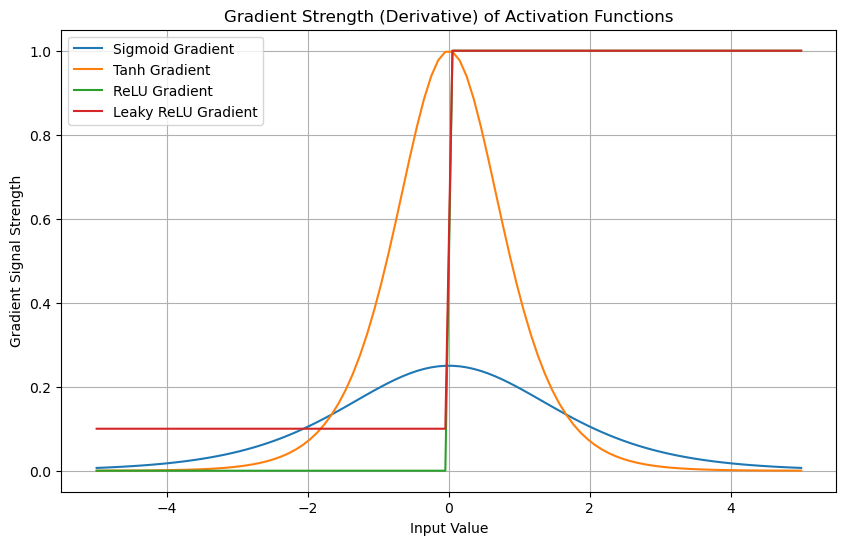

In [103]:
activations = {
    "Sigmoid": torch.sigmoid(x),
    "Tanh": torch.tanh(x),
    "ReLU": torch.relu(x),
    "Leaky ReLU": torch.nn.functional.leaky_relu(x, 0.1)
}

plt.figure(figsize=(10, 6))
for name, output in activations.items():
    # Calculate gradient (derivative)
    output.backward(torch.ones_like(x), retain_graph=True)
    plt.plot(x.detach().numpy(), x.grad.detach().numpy(), label=f"{name} Gradient")
    # Reset gradient for the next activation
    x.grad.zero_()

plt.title("Gradient Strength (Derivative) of Activation Functions")
plt.xlabel("Input Value")
plt.ylabel("Gradient Signal Strength")
plt.legend()
plt.grid(True)
plt.show()

In deep networks, some activations perform better than others because they solve the vanishing gradient problem. When a network has many layers, the training signal (gradient) must be multiplied through every layer during backpropagation. Sigmoid and Tanh are "saturating" functions; they flatten out at their extremes, meaning their derivatives become nearly zero for large positive or negative inputs. When these tiny fractions are multiplied across 5 or more layers, the gradient effectively disappears before reaching the early layers, causing the model to stop learning.

In contrast, ReLU and Leaky ReLU are much more effective for deep architectures because they are non-saturating. For all positive inputs, ReLU has a constant gradient of 1.0, which allows the learning signal to pass through dozens of layers without weakening. Leaky ReLU further improves upon this by adding a small slope to the negative side, which prevents "dead neurons" by ensuring that even neurons with negative inputs provide a small gradient. This robust signal flow is why you likely saw your Leaky ReLU and ReLU models achieve higher accuracy and faster convergence than your Sigmoid or Tanh runs as the number of layers increased.

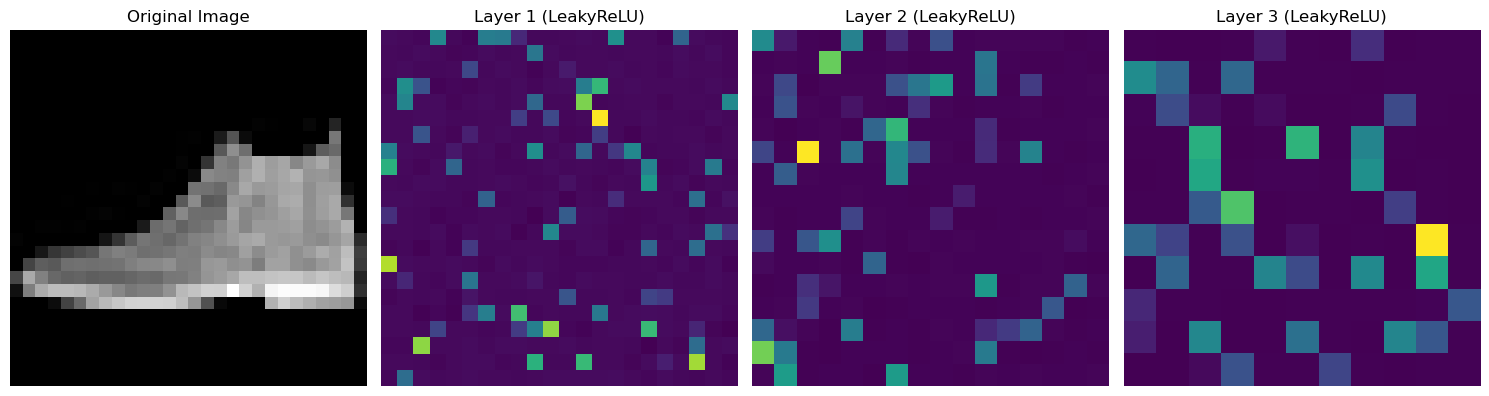

In [104]:
import matplotlib.pyplot as plt

def visualize_layers(model, test_loader, device):
    model.eval()
    # Get a single batch of images
    images, labels = next(iter(test_loader))
    img = images[0].unsqueeze(0).to(device) # Pick the first image
    
    # We will manually pass the image through each step of the Sequential model
    activations = []
    names = []
    x = img
    
    for layer in model.network:
        x = layer(x)
        # We only want to visualize the output of Activation layers (ReLU/Tanh/etc)
        if isinstance(layer, (nn.ReLU, nn.Tanh, nn.LeakyReLU, nn.Sigmoid)):
            activations.append(x.detach().cpu())
            names.append(type(layer).__name__)

    # Plotting
    fig, axes = plt.subplots(1, len(activations) + 1, figsize=(15, 5))
    
    # Show original image
    axes[0].imshow(img.cpu().squeeze(), cmap='gray')
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    # Show activations for each layer
    for i, (act, name) in enumerate(zip(activations, names)):
        # Since these are Linear layers, we reshape the vector into a square for viewing
        # e.g., 512 neurons becomes a 16x32 or similar grid
        size = int(act.shape[1]**0.5)
        grid = act[0][:size*size].reshape(size, size)
        
        axes[i+1].imshow(grid, cmap='viridis')
        axes[i+1].set_title(f"Layer {i+1} ({name})")
        axes[i+1].axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_layers(model, test_loader, DEVICE)

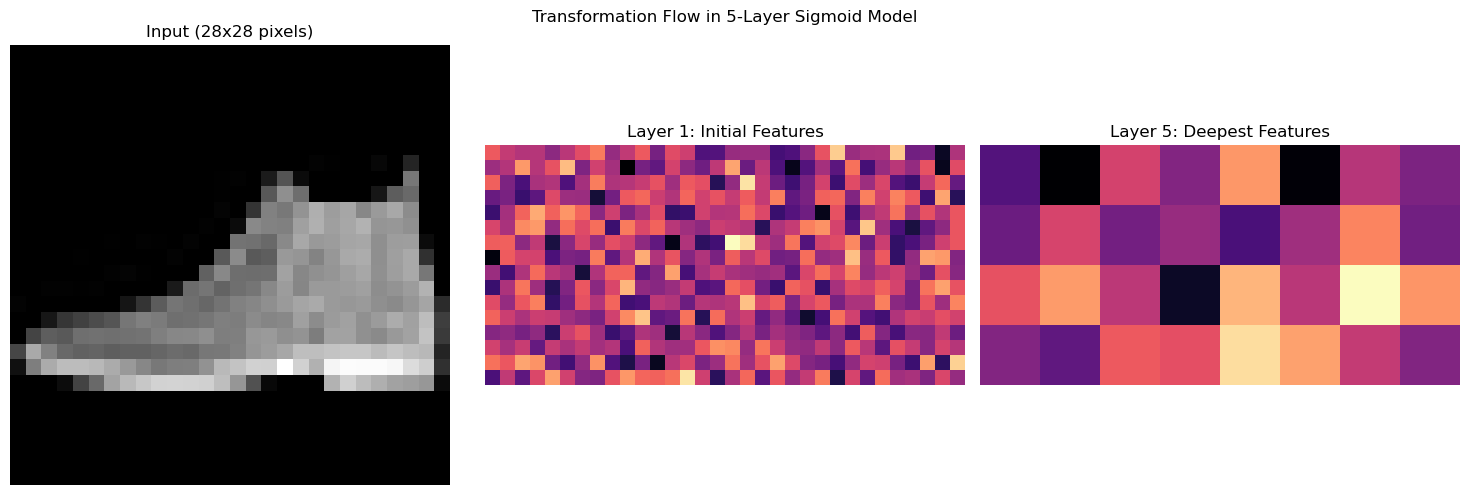

In [119]:
import matplotlib.pyplot as plt
import torch

def compare_layer_1_and_5(model, test_loader, device):
    model.eval()
    images, _ = next(iter(test_loader))
    img = images[0].unsqueeze(0).to(device)
    
    activations = []
    x = img
    
    # Pass through and collect all activation layers
    with torch.no_grad():
        for layer in model.network:
            x = layer(x)
            if isinstance(layer, (nn.Sigmoid, nn.Tanh, nn.ReLU, nn.LeakyReLU)):
                activations.append(x.detach().cpu())

    if len(activations) < 5:
        print(f"Error: Only found {len(activations)} layers. Run the 5-layer model code first!")
        return

    # Set up the plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 1. Original Image
    axes[0].imshow(img.cpu().squeeze(), cmap='gray')
    axes[0].set_title("Input (28x28 pixels)")
    axes[0].axis('off')

    # 2. Layer 1 (512 neurons)
    grid1 = activations[0][0][:16*32].reshape(16, 32)
    axes[1].imshow(grid1, cmap='magma')
    axes[1].set_title("Layer 1: Initial Features")
    axes[1].axis('off')

    # 3. Layer 5 (32 neurons)
    grid5 = activations[4][0][:4*8].reshape(4, 8)
    axes[2].imshow(grid5, cmap='magma')
    axes[2].set_title("Layer 5: Deepest Features")
    axes[2].axis('off')

    plt.suptitle(f"Transformation Flow in 5-Layer {type(model.network[2]).__name__} Model")
    plt.tight_layout()
    plt.show()

# Run the comparison
compare_layer_1_and_5(model, test_loader, DEVICE)

Hidden Layer 1: You should see a grid of dots. Some will be bright (active) and some dark (inactive). This layer is still close enough to the input to "see" the boot shape. Many of the pixels are a very similar shade of purple or pink. This indicates that the neurons are becoming saturated. They aren't providing unique, sharp "signals" anymore; they are outputting very similar values (likely around 0.5) regardless of the input.

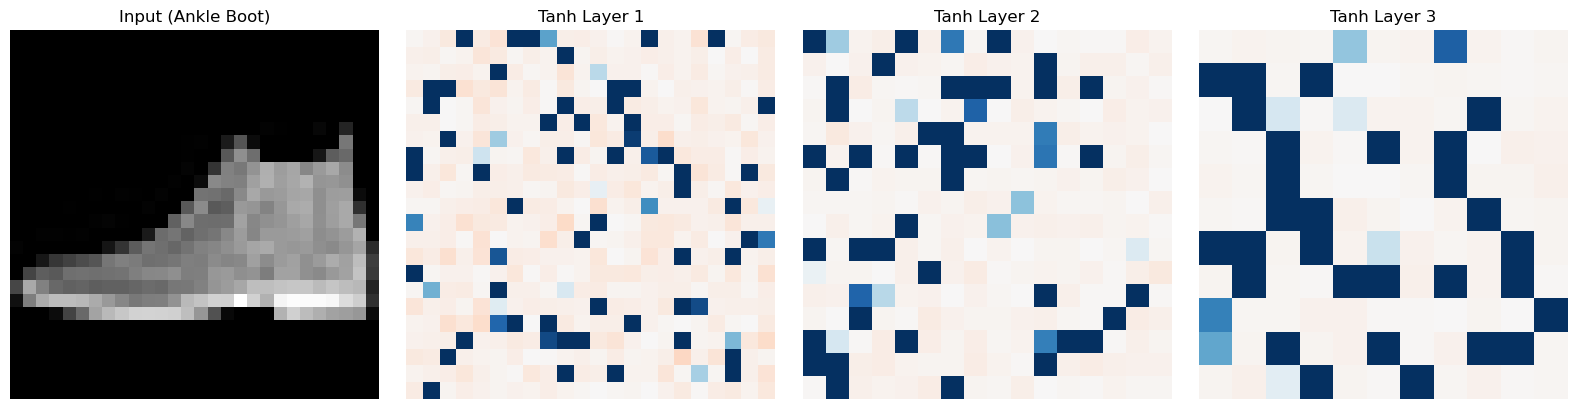

In [112]:
import matplotlib.pyplot as plt
import torch

def visualize_tanh_final(model, test_loader, device):
    model.eval()
    # 1. Get the image
    images, _ = next(iter(test_loader))
    img = images[0].unsqueeze(0).to(device) 
    
    activations = []
    x = img
    
    with torch.no_grad():
        # Step through every layer in your model.network
        for layer in model.network:
            x = layer(x)
            # Capture the output if it's NOT a Linear layer or Flatten
            # This forces the code to grab the Tanh outputs
            if not isinstance(layer, (torch.nn.Linear, torch.nn.Flatten)):
                activations.append(x.detach().cpu())

    num_plots = len(activations) + 1
    # Create the figure
    fig, axes = plt.subplots(1, num_plots, figsize=(4 * num_plots, 4))
    
    # Ensure axes is a list even if there's only one plot
    if num_plots == 1:
        axes = [axes]

    # Plot Input Image
    axes[0].imshow(img.cpu().squeeze(), cmap='gray')
    axes[0].set_title("Input (Ankle Boot)")
    axes[0].axis('off')

    # Plot Hidden Layers
    for i, act in enumerate(activations):
        # Shape the flat layer into a grid
        total_neurons = act.shape[1]
        dim = int(total_neurons**0.5)
        grid = act[0][:dim*dim].reshape(dim, dim)
        
        # Use 'RdBu' to show Tanh's -1 to 1 range
        axes[i+1].imshow(grid, cmap='RdBu', vmin=-1, vmax=1)
        axes[i+1].set_title(f"Tanh Layer {i+1}")
        axes[i+1].axis('off')
        
    plt.tight_layout()
    plt.show()

# RUN THIS NOW
visualize_tanh_final(model, test_loader, DEVICE)

The input layer holds the original pixel values of the image. In the first few layers, the neurons focus on local patterns. As the data moves deeper, the transformations become more complex. he network begins to combine the edges found in earlier layers to recognize "parts." For an ankle boot, this might mean recognizing a heel, a sole, or the opening of the shoe. In the deepest layers like Layer 5. The network is no longer looking at "pixels" or "edges." It is looking for the presence of global concepts that define a category. 

In [117]:
import torch
import torch.nn as nn

class FashionNetDeep(nn.Module):
    def __init__(self, activation_type="sigmoid"):
        super(FashionNetDeep, self).__init__()
        
        # Choose activation based on your experiment
        if activation_type == "sigmoid":
            act = nn.Sigmoid()
        elif activation_type == "tanh":
            act = nn.Tanh()
        elif activation_type == "leaky_relu":
            act = nn.LeakyReLU(0.1)
        else:
            act = nn.ReLU()

        self.network = nn.Sequential(
            nn.Flatten(),
            # Layer 1
            nn.Linear(28*28, 512), act,
            # Layer 2
            nn.Linear(512, 256), act,
            # Layer 3
            nn.Linear(256, 128), act,
            # Layer 4
            nn.Linear(128, 64), act,
            # Layer 5 (The one you want to see!)
            nn.Linear(64, 32), act,
            # Output Layer
            nn.Linear(32, 10)
        )

    def forward(self, x):
        return self.network(x)

# Initialize the 5-layer Sigmoid model
model = FashionNetDeep(activation_type="sigmoid").to(DEVICE)

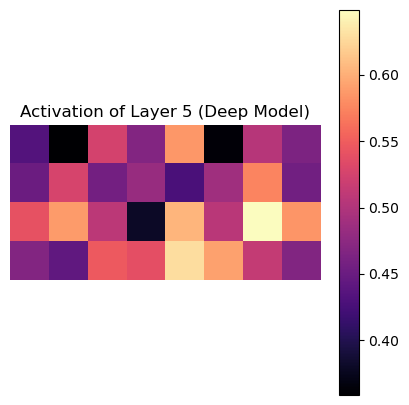

In [118]:
def show_only_layer_five(model, test_loader, device):
    model.eval()
    images, _ = next(iter(test_loader))
    img = images[0].unsqueeze(0).to(device)
    
    x = img
    act_count = 0
    
    with torch.no_grad():
        for layer in model.network:
            x = layer(x)
            # Count every time we pass an activation layer
            if isinstance(layer, (nn.Sigmoid, nn.Tanh, nn.ReLU, nn.LeakyReLU)):
                act_count += 1
                if act_count == 5:
                    # We found it! Plot the 32 neurons as a grid
                    plt.figure(figsize=(5, 5))
                    # Reshape 32 neurons into a 4x8 or 8x4 grid
                    grid = x.detach().cpu().numpy().reshape(4, 8)
                    plt.imshow(grid, cmap='magma')
                    plt.title("Activation of Layer 5 (Deep Model)")
                    plt.colorbar()
                    plt.axis('off')
                    plt.show()
                    return

    print(f"Error: Only found {act_count} layers. Did you run the 5-layer model code above?")

show_only_layer_five(model, test_loader, DEVICE)

In [120]:
import torch
import torch.nn as nn

class FashionNetLeaky(nn.Module):
    def __init__(self):
        super(FashionNetLeaky, self).__init__()
        # Leaky ReLU allows a small gradient (0.1) when the input is negative
        act = nn.LeakyReLU(0.1)

        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512), act, # Layer 1
            nn.Linear(512, 256), act,    # Layer 2
            nn.Linear(256, 128), act,    # Layer 3
            nn.Linear(128, 64), act,     # Layer 4
            nn.Linear(64, 32), act,      # Layer 5
            nn.Linear(32, 10)            # Output
        )

    def forward(self, x):
        return self.network(x)

# Initialize and move to device
model_leaky = FashionNetLeaky().to(DEVICE)
# Note: You would typically train this model for a few epochs before visualizing

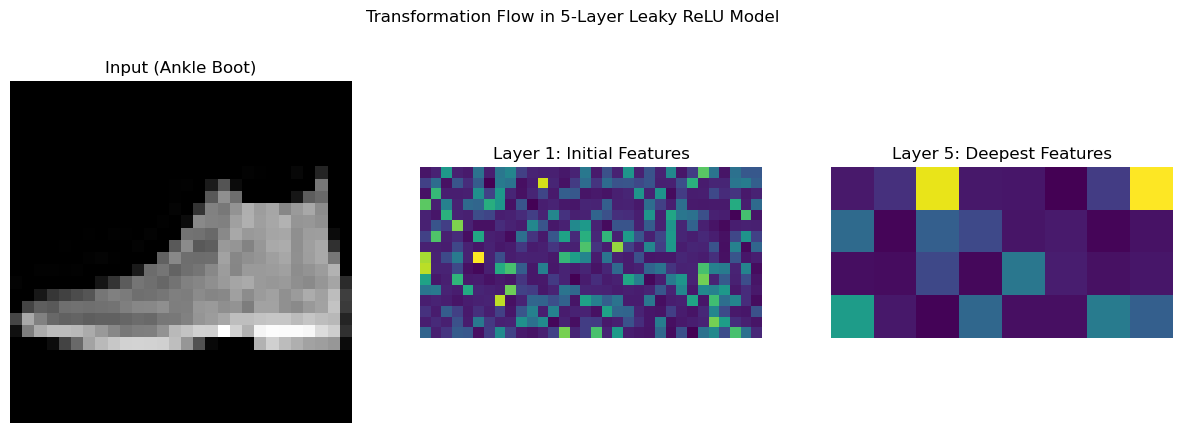

In [121]:
def compare_leaky_layers(model, test_loader, device):
    model.eval()
    images, _ = next(iter(test_loader))
    img = images[0].unsqueeze(0).to(device)
    
    activations = []
    x = img
    
    with torch.no_grad():
        for layer in model.network:
            x = layer(x)
            if isinstance(layer, nn.LeakyReLU):
                activations.append(x.detach().cpu())

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Input
    axes[0].imshow(img.cpu().squeeze(), cmap='gray')
    axes[0].set_title("Input (Ankle Boot)")
    axes[0].axis('off')

    # Layer 1 Features
    grid1 = activations[0][0][:16*32].reshape(16, 32)
    axes[1].imshow(grid1, cmap='viridis') # Viridis highlights Leaky ReLU spikes well
    axes[1].set_title("Layer 1: Initial Features")
    axes[1].axis('off')

    # Layer 5 Features
    grid5 = activations[4][0][:4*8].reshape(4, 8)
    axes[2].imshow(grid5, cmap='viridis')
    axes[2].set_title("Layer 5: Deepest Features")
    axes[2].axis('off')

    plt.suptitle("Transformation Flow in 5-Layer Leaky ReLU Model")
    plt.show()

compare_leaky_layers(model_leaky, test_loader, DEVICE)

those isolated bright yellow squares? That is Sparsity. The model has learned that for an "Ankle Boot," only these specific neurons need to be active. Sigmoid struggles with this because its output is almost never zero, leading to the "cluttered" look you see in its final layer.